In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [2]:
dataset_folder =r"C:\Users\shaya\Downloads\archive\cell_images"

infected_paths = glob(os.path.join(dataset_folder, "infected", "*.png"))
uninfected_paths = glob(os.path.join(dataset_folder, "Uninfected", "*.png"))

print("Parasitized:", len(infected_paths))
print("Uninfected:", len(uninfected_paths))


Parasitized: 13779
Uninfected: 13779


In [3]:
IMG_SIZE = (64, 64)

X = []
y = []

def load_and_resize(path, label):
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img) / 255.0
    X.append(img)
    y.append(label)

for p in infected_paths:
    load_and_resize(p, 1)

for p in uninfected_paths:
    load_and_resize(p, 0)

X = np.array(X)
y = np.array(y)
y = to_categorical(y, 2)

print("Dataset shape:", X.shape)


Dataset shape: (27558, 64, 64, 3)


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (20668, 64, 64, 3)
Val: (3445, 64, 64, 3)
Test: (3445, 64, 64, 3)


In [6]:
train_aug = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_aug = ImageDataGenerator()
test_aug = ImageDataGenerator()


In [7]:
def create_cnn_model(input_shape, num_classes=2):
    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.4))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

model = create_cnn_model((64, 64, 3))
model.summary()


C:\Users\shaya\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         524,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 617,730 (2.36 MB)

 Trainable params: 617,730 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

history = model.fit(
    train_aug.flow(X_train, y_train, batch_size=32),
    validation_data=val_aug.flow(X_val, y_val),
    epochs=50,
    # callbacks=[early_stop]
)


C:\Users\shaya\miniconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 67s 100ms/step - accuracy: 0.7827 - loss: 0.4447 - val_accuracy: 0.9509 - val_loss: 0.1734
Epoch 2/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 80s 98ms/step - accuracy: 0.9232 - loss: 0.2340 - val_accuracy: 0.9521 - val_loss: 0.1438
Epoch 3/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 64s 99ms/step - accuracy: 0.9289 - loss: 0.2147 - val_accuracy: 0.9559 - val_loss: 0.1358
Epoch 4/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 80s 96ms/step - accuracy: 0.9309 - loss: 0.2061 - val_accuracy: 0.9504 - val_loss: 0.1438
Epoch 5/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 64s 99ms/step - accuracy: 0.9338 - loss: 0.2017 - val_accuracy: 0.9576 - val_loss: 0.1350
Epoch 6/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 65s 100ms/step - accuracy: 0.9371 - loss: 0.1907 - val_accuracy: 0.9538 - val_loss: 0.1474
Epoch 7/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 66s 102ms/step - accuracy: 0.9376 - loss: 0.1860 - val_accuracy: 0.9562 - val_loss: 0.1481
Epoch 8/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 66s 102ms/step - accuracy: 0.9381 - loss: 0.184

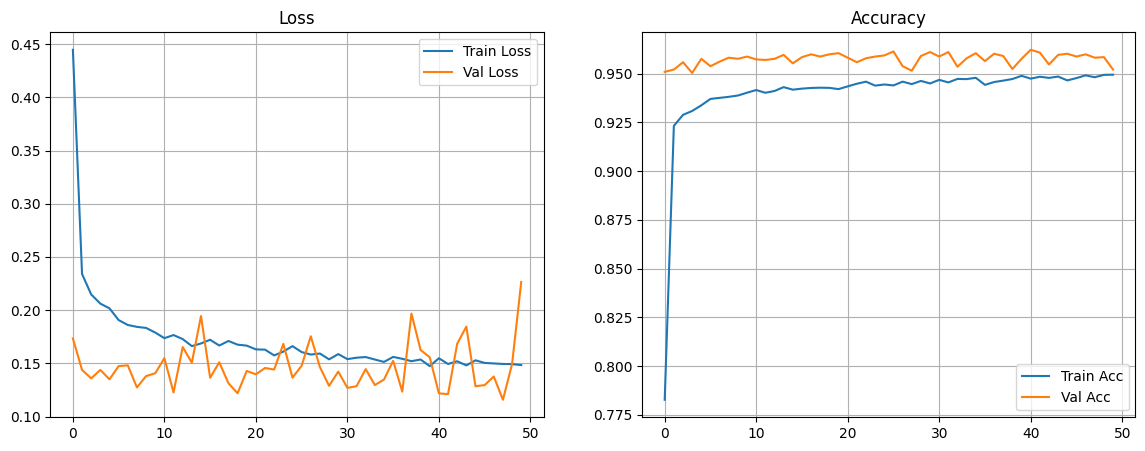

In [9]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.grid()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.grid()
plt.title("Accuracy")

plt.show()


In [10]:
test_loss, test_acc = model.evaluate(test_aug.flow(X_test, y_test))
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9472 - loss: 0.2187
Test Accuracy: 0.947169840335846
Test Loss: 0.21869365870952606


108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.55      0.53      1726
           1       0.51      0.47      0.49      1719

    accuracy                           0.51      3445
   macro avg       0.51      0.51      0.51      3445
weighted avg       0.51      0.51      0.51      3445



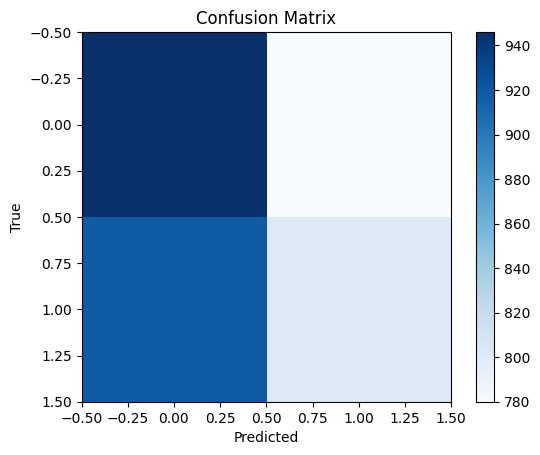

In [11]:
y_pred = model.predict(test_aug.flow(X_test))
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [13]:
def predict_image(path):
    img = load_img(path, target_size=(64,64))
    img_arr = img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    pred = model.predict(img_arr)
    label = np.argmax(pred)

    print("Prediction:", "Infected" if label == 1 else "Uninfected")
    return label

predict_image(r"C:\Users\shaya\Downloads\archive\cell_images\infected\001.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Prediction: Infected


np.int64(1)